# 📊 サブカテゴリ別 顧客単価 × 利益率マップ

サブカテゴリごとの顧客単価と利益率を4象限で表示する。
円の大きさは売上の相対値を表す。

> ※ 本notebookはローカルモジュール（`Lv01_03_configuration`）に依存しているため、単体での実行はできません。分析の流れとアウトプットの確認を目的としています。

In [ ]:
# ================================================ #
# imports
# ================================================ #

# 標準ライブラリ
import sys
from pathlib import Path

# 外部ライブラリ
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from adjustText import adjust_text
from IPython.display import display

# ローカルモジュール
%load_ext autoreload
%autoreload 2
sys.path.insert(0, str(Path.cwd().parents[1]))
sys.path.insert(0, str(Path.cwd().parents[2]))
from Lv01_03_configuration.cnfg_b_dir_01_local import DIRS
from Lv01_03_configuration.cnfg_d_proc_01_merged import Proc01info, Cols, Items
from Lv01_03_configuration.cnfg_u_local_02_function import generate_dic_ym_to_fiscal_quarter
from Lv01_03_configuration.cnfg_p_chart import generate_chart_scatter_subcat
from Lv01_03_configuration.cnfg_a_api_01_pub import (
    pmod_01_loading_df as func_loading_df,
    pmod_20_formatting_datetime as func_datetime_format,
)

In [ ]:
# ================================================ #
# データ読み込み・加工
# ================================================ #

# データ読み込み
df = func_loading_df.read_as_dataframe_from_excel_or_csv(
    target_file_path=Path(DIRS.Processed) / Proc01info.FILENAME
)

# 年月カラムの追加
df = (
    df.copy()
    .pipe(
        func_datetime_format.format_ss_half_y4m2,
        target_col        = Cols.order_date,
        output_col        = Cols.order_ym,
        trans_to_datetime = True
    )
)

# 集計期間の設定
fiscal_start_month = 1
start_year         = 2025
start_month        = 1
end_year           = start_year
end_month          = 12

dic_current_quarter = generate_dic_ym_to_fiscal_quarter(
    fiscal_start_month = fiscal_start_month,
    start_year         = start_year,
    start_month        = start_month,
    end_year           = end_year,
    end_month          = end_month
)
current_list_full = list(dic_current_quarter)
current_list      = current_list_full[:7]

current_df = (
    df.loc[df[Cols.order_ym].isin(current_list)]
    .copy()
    .reset_index(drop=True)
)

# バブルカラーの付与
current_df["bubble_color"] = current_df[Cols.category].map(Items.dark_color_map_procat())

# サブカテゴリ別集計
df_subcat = (
    current_df
    .groupby(Cols.sub_category, as_index=False)
    .agg(
        sales_sum    = (Cols.sales, "sum"),
        profit_sum   = (Cols.profit, "sum"),
        customer_cnt = (Cols.customer_id, "nunique"),
        bubble_color = ("bubble_color", "first")
    )
)

df_subcat["customer_unit_price"] = df_subcat["sales_sum"] / df_subcat["customer_cnt"]
df_subcat["profit_ratio"]        = df_subcat["profit_sum"] / df_subcat["sales_sum"]

# 正規化関数
def normalize_to_minus1_plus1(s: pd.Series) -> pd.Series:
    s_min, s_max = s.min(), s.max()
    if s_max == s_min:
        return pd.Series(0, index=s.index)
    return 2 * (s - s_min) / (s_max - s_min) - 1

def normalize_to_0_1(s: pd.Series) -> pd.Series:
    s_min, s_max = s.min(), s.max()
    if s_max == s_min:
        return pd.Series(0.5, index=s.index)
    return (s - s_min) / (s_max - s_min)

# 正規化
df_subcat["unit_price_norm"]   = normalize_to_minus1_plus1(df_subcat["customer_unit_price"])
df_subcat["profit_ratio_norm"] = normalize_to_minus1_plus1(df_subcat["profit_ratio"])
df_subcat["sales_sum_norm"]    = normalize_to_0_1(df_subcat["sales_sum"])
df_subcat["bubble_size"]       = 100 + df_subcat["sales_sum_norm"] * 600

# サブカテゴリの日本語マッピング
dic_sub_category_jp = {
    "Appliances" : "家電・事務機器",
    "Art"        : "画材",
    "Binders"    : "バインダー",
    "Envelopes"  : "封筒",
    "Fasteners"  : "留め具",
    "Labels"     : "ラベル",
    "Paper"      : "用紙",
    "Storage"    : "収納",
    "Supplies"   : "消耗品",
    "Bookcases"  : "本棚",
    "Chairs"     : "椅子",
    "Furnishings": "インテリア",
    "Tables"     : "テーブル",
    "Accessories": "アクセサリ",
    "Copiers"    : "コピー機",
    "Machines"   : "機器",
    "Phones"     : "電話機",
}


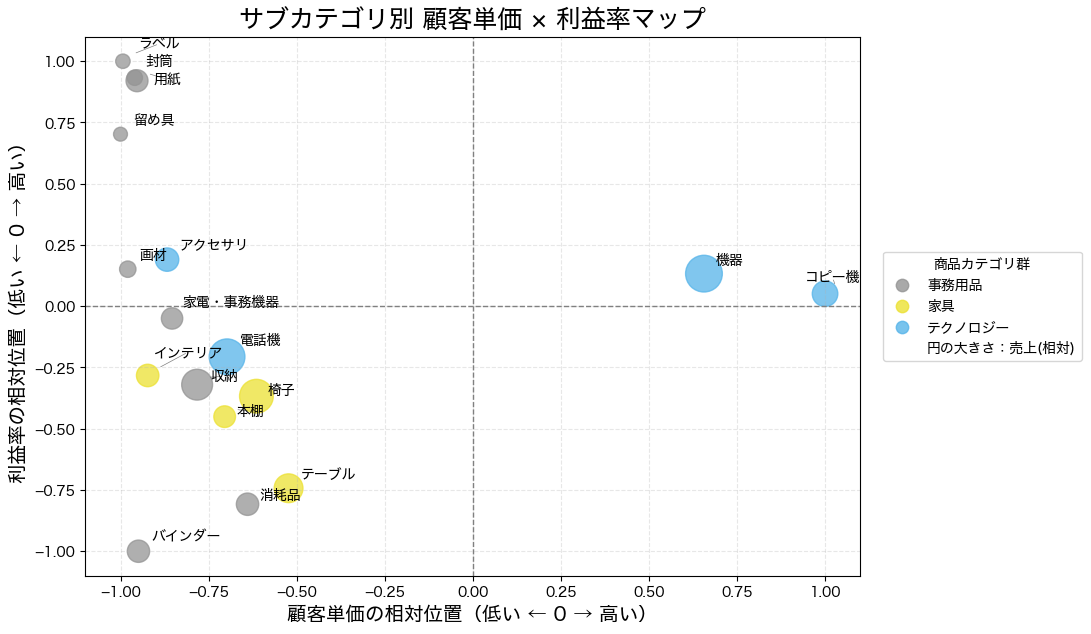

In [4]:
# ================================================ #
# チャート生成
# ================================================ #

plt.rcParams['font.family'] = 'Hiragino Sans'
fig, ax = plt.subplots(figsize=(10, 7))

generate_chart_scatter_subcat(
    df_subcat          = df_subcat,
    ax                 = ax,
    dic_sub_category_jp = dic_sub_category_jp,
    title              = "サブカテゴリ別 顧客単価 × 利益率マップ",
)

plt.show()